In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [8]:
data=pd.read_csv("sales.csv")

## EDA

In [22]:
data.head(20)

,Product_Identifier,Product_Weight,Product_Fat_Content,Product_Visibility,Product_Type,Product_MRP,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Product_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,1987,High,Tier 3,Supermarket Type1,994.7052
5,FDP36,10.395,Regular,0.000000,Baking Goods,51.4008,2009,Medium,Tier 3,Supermarket Type2,556.6088
6,FDO10,13.650,Regular,0.012741,Snack Foods,57.6588,1987,High,Tier 3,Supermarket Type1,343.5528
7,FDP10,NaN,Low Fat,0.127470,Snack Foods,107.7622,1985,Medium,Tier 3,Supermarket Type3,4022.7636
8,FDH17,16.200,Regular,0.016687,Frozen Foods,96.9726,2002,NaN,Tier 2,Supermarket Type1,1076.5986
9,FDU28,19.200,Regular,0.094450,Frozen Foods,187.8214,2007,NaN,Tier 2,Supermarket Type1,4710.5350


In [10]:
data.describe()

,Product_Weight,Product_Visibility,Product_MRP,Outlet_Establishment_Year,Product_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [12]:
data.shape

(8523, 11)

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Identifier         8523 non-null   object 
 1   Product_Weight             7060 non-null   float64
 2   Product_Fat_Content        8523 non-null   object 
 3   Product_Visibility         8523 non-null   float64
 4   Product_Type               8523 non-null   object 
 5   Product_MRP                8523 non-null   float64
 6   Outlet_Establishment_Year  8523 non-null   int64  
 7   Outlet_Size                6113 non-null   object 
 8   Outlet_Location_Type       8523 non-null   object 
 9   Outlet_Type                8523 non-null   object 
 10  Product_Outlet_Sales       8523 non-null   float64
dtypes: float64(4), int64(1), object(6)
memory usage: 732.6+ KB


In [15]:
data.isnull().sum()

Product_Identifier              0
Product_Weight               1463
Product_Fat_Content             0
Product_Visibility              0
Product_Type                    0
Product_MRP                     0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Product_Outlet_Sales            0
dtype: int64

In [77]:
data['Product_Fat_Content'].unique()

array(['Low Fat', 'Regular', 'low fat', 'LF', 'reg'], dtype=object)

## Data Cleaning

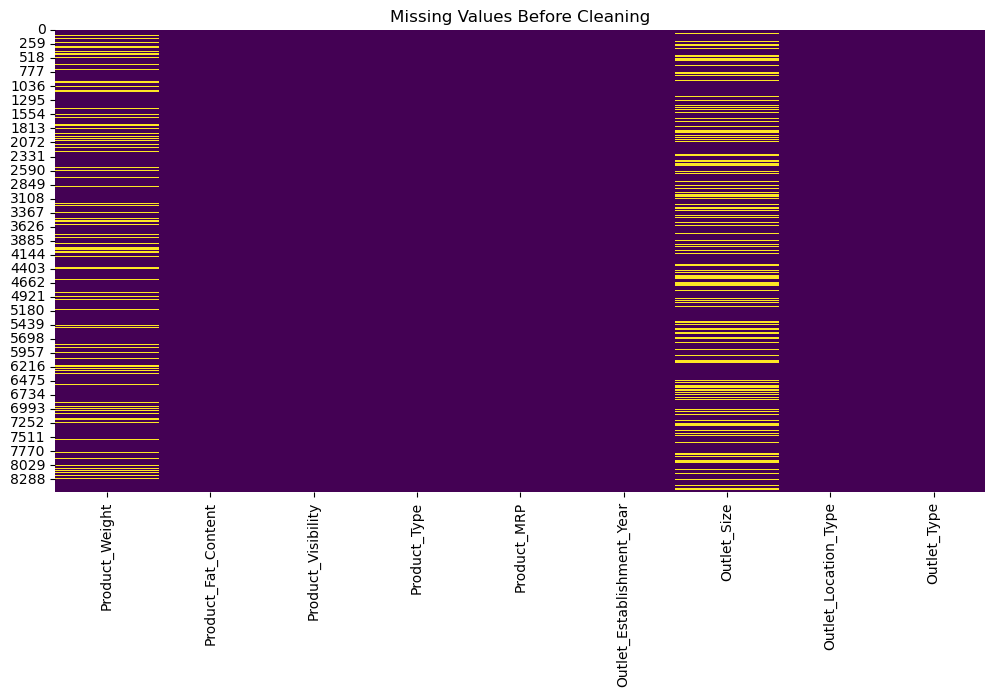

In [23]:
plt.figure(figsize=(12,6))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Before Cleaning")
plt.show()

In [191]:
data['Product_Weight'].fillna(data['Product_Weight'].median(), inplace=True)

/var/folders/q0/m60vkbkx0fl3nwst67g0ny2h0000gn/T/ipykernel_57667/3688916710.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Product_Weight'].fillna(data['Product_Weight'].median(), inplace=True)


In [192]:
data['Outlet_Size'].fillna(data['Outlet_Size'].mode()[0], inplace=True)

/var/folders/q0/m60vkbkx0fl3nwst67g0ny2h0000gn/T/ipykernel_57667/1434104270.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Outlet_Size'].fillna(data['Outlet_Size'].mode()[0], inplace=True)


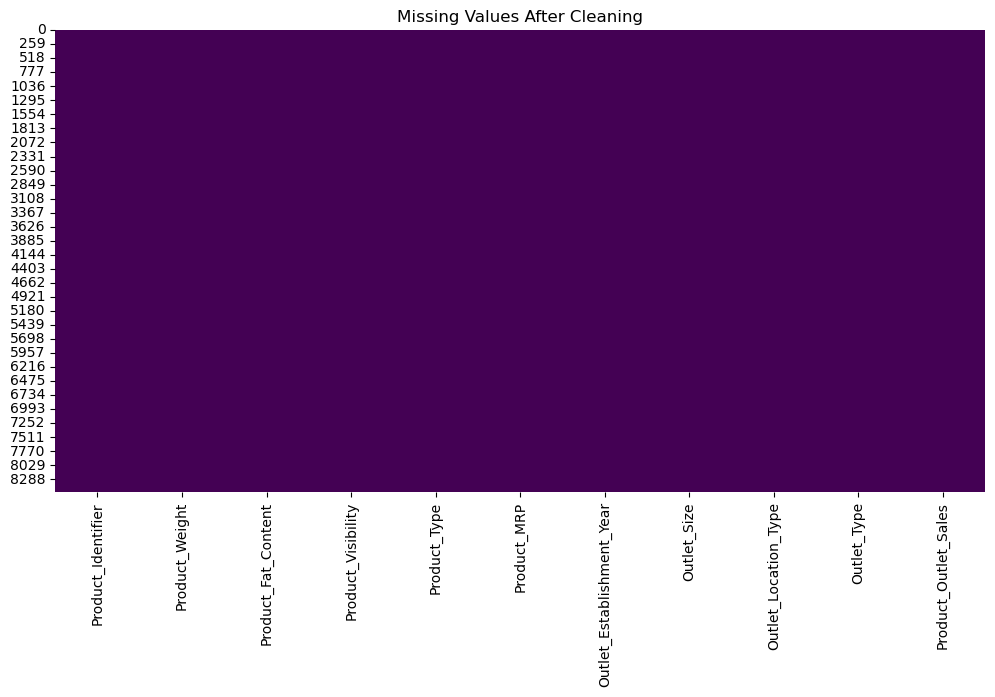

In [193]:
plt.figure(figsize=(12,6))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values After Cleaning")
plt.show()

In [194]:
data['Product_Fat_Content'] = data['Product_Fat_Content'].replace({
    'LF': 'Low Fat',
    'low fat': 'Low Fat',
    'reg': 'Regular'
})

In [195]:
data['Product_Fat_Content'].unique()

array(['Low Fat', 'Regular'], dtype=object)

In [196]:
y = data['Product_Outlet_Sales']

In [197]:
x = data.drop(columns=['Product_Identifier','Product_Outlet_Sales'])

In [198]:
num_colm = x.select_dtypes(include=['int64', 'float64']).columns
cat_colm = x.select_dtypes(include=['object']).columns
print(num_colm)
print(cat_colm)

Index(['Product_Weight', 'Product_Visibility', 'Product_MRP',
       'Outlet_Establishment_Year'],
      dtype='object')
Index(['Product_Fat_Content', 'Product_Type', 'Outlet_Size',
       'Outlet_Location_Type', 'Outlet_Type'],
      dtype='object')


In [199]:
x = pd.get_dummies(x, drop_first=True)

In [200]:
x

,Product_Weight,Product_Visibility,Product_MRP,Outlet_Establishment_Year,Product_Fat_Content_Regular,Product_Type_Breads,Product_Type_Breakfast,Product_Type_Canned,Product_Type_Dairy,Product_Type_Frozen Foods,...,Product_Type_Snack Foods,Product_Type_Soft Drinks,Product_Type_Starchy Foods,Outlet_Size_Medium,Outlet_Size_Small,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,9.300,0.016047,249.8092,1999,False,False,False,False,True,False,...,False,False,False,True,False,False,False,True,False,False
1,5.920,0.019278,48.2692,2009,True,False,False,False,False,False,...,False,True,False,True,False,False,True,False,True,False
2,17.500,0.016760,141.6180,1999,False,False,False,False,False,False,...,False,False,False,True,False,False,False,True,False,False
3,19.200,0.000000,182.0950,1998,True,False,False,False,False,False,...,False,False,False,True,False,False,True,False,False,False
4,8.930,0.000000,53.8614,1987,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8518,6.865,0.056783,214.5218,1987,False,False,False,False,False,False,...,True,False,False,False,False,False,True,True,False,False
8519,8.380,0.046982,108.1570,2002,True,False,False,False,False,False,...,False,False,False,True,False,True,False,True,False,False
8520,10.600,0.035186,85.1224,2004,False,False,False,False,False,False,...,False,False,False,False,True,True,False,True,False,False
8521,7.210,0.145221,103.1332,2009,True,False,False,False,False,False,...,True,False,False,True,False,False,True,False,True,False


## Train test split 

In [201]:
from sklearn.model_selection import train_test_split

In [202]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

## Scale 

In [203]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

## Algorithm Setup

In [204]:
from sklearn.linear_model import LinearRegression

In [205]:
lm = LinearRegression()

In [206]:
lm.fit(x_train, y_train)

LinearRegression()

## Model evaluation 

In [207]:
print('Intercept: ',lm.intercept_)

Intercept:  2202.3652312114978


In [208]:
predictions = lm.predict(x_test)

In [209]:
from sklearn import metrics

In [210]:
print('Mean Absolute Error (MAE):', metrics.mean_absolute_error(y_test, predictions))  
print('Mean Squared Error (MSE):', metrics.mean_squared_error(y_test, predictions))  
print('Root Mean Squared Error (RMSE):', np.sqrt(metrics.mean_squared_error(y_test, predictions)))

Mean Absolute Error (MAE): 791.5962967286051
Mean Squared Error (MSE): 1142642.1589291962
Root Mean Squared Error (RMSE): 1068.9444133953814


In [211]:
print("R2-score:", metrics.r2_score(y_test, predictions))

R2-score: 0.579597224795218


In [226]:
print("Original number of features:", x_train.shape[1])

Original number of features: 27


## MODEL 2 

In [212]:
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

In [221]:
model2 = Pipeline(steps=[
    ('scaler', StandardScaler()), 
    ('pca', PCA(n_components=0.99)),                
    ('regressor', LinearRegression())
])

model2.fit(x_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA(n_components=0.99)),
                ('regressor', LinearRegression())])

In [222]:
predictions2 = model2.predict(x_test)

In [223]:
print('Mean Absolute Error (MAE):', metrics.mean_absolute_error(y_test, predictions2))  
print('Mean Squared Error (MSE):', metrics.mean_squared_error(y_test, predictions2))  
print('Root Mean Squared Error (RMSE):', np.sqrt(metrics.mean_squared_error(y_test, predictions2)))

Mean Absolute Error (MAE): 790.4838875695146
Mean Squared Error (MSE): 1143477.0027944879
Root Mean Squared Error (RMSE): 1069.3348412889611


In [224]:
print("R2-score:", metrics.r2_score(y_test, predictions2))

R2-score: 0.5792900676725015


## Model Comparisons 

In [236]:
print("Original number of features:", x_train.shape[1])
print("Number of PCA components:", model2.named_steps['pca'].n_components_)
print("Total explained variance:", pca_step.explained_variance_ratio_.sum())

Original number of features: 27
Number of PCA components: 24
Total explained variance: 0.9933564605004227


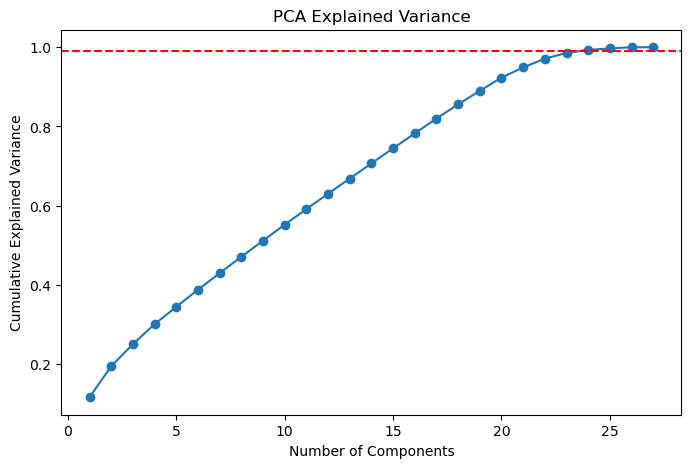

In [234]:
pca = PCA()
x_scaled = StandardScaler().fit_transform(x_train)
pca.fit(x_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.axhline(y=0.99, color='r', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.show()

3. Compare the performance of the two models.

The performance of the full-feature model and the PCA-based model is nearly identical. Both models achieved similar values for MAE (~791), RMSE (~1069), and R² (~0.58), indicating that dimensionality reduction did not significantly impact predictive performance.

This suggests that the majority of the information in the original feature set was preserved after applying PCA. Even though the PCA model reduced the dimensionality of the data, it retained enough variance to maintain the same level of predictive accuracy.

Therefore, the PCA model achieves comparable performance while using fewer dimensions, demonstrating that some of the original features contained redundant information. 

4. Explain how you determined the number of features to keep in the second model.

The number of features in the PCA model was determined using a variance retention threshold of 0.99. PCA was applied after scaling the data, and the number of components was automatically selected to retain at least 99% of the total variance in the predictor variables.

As a result, the dimensionality was reduced from 27 original features to 24 principal components, while preserving approximately 99.33% of the variance. This approach ensures that most of the information in the dataset is retained while reducing redundancy among features.